In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries successfully imported!")



Libraries successfully imported!


In [12]:
df = pd.read_csv(r"D:\ML_PROJECTS\Student_Performance_Prediction\StudentsPerformance.csv")

display(df.head())

print(f"Dataset Shape: {df.shape}")

print("\nMissing Values:")
print(df.isnull().sum())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Dataset Shape: (1000, 8)

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


C:\Users\Mahar Faisal\AppData\Local\Temp\ipykernel_3856\1652373819.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='math score', data=df, palette='Set2')
C:\Users\Mahar Faisal\AppData\Local\Temp\ipykernel_3856\1652373819.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='test preparation course', y='math score', data=df, palette='viridis')


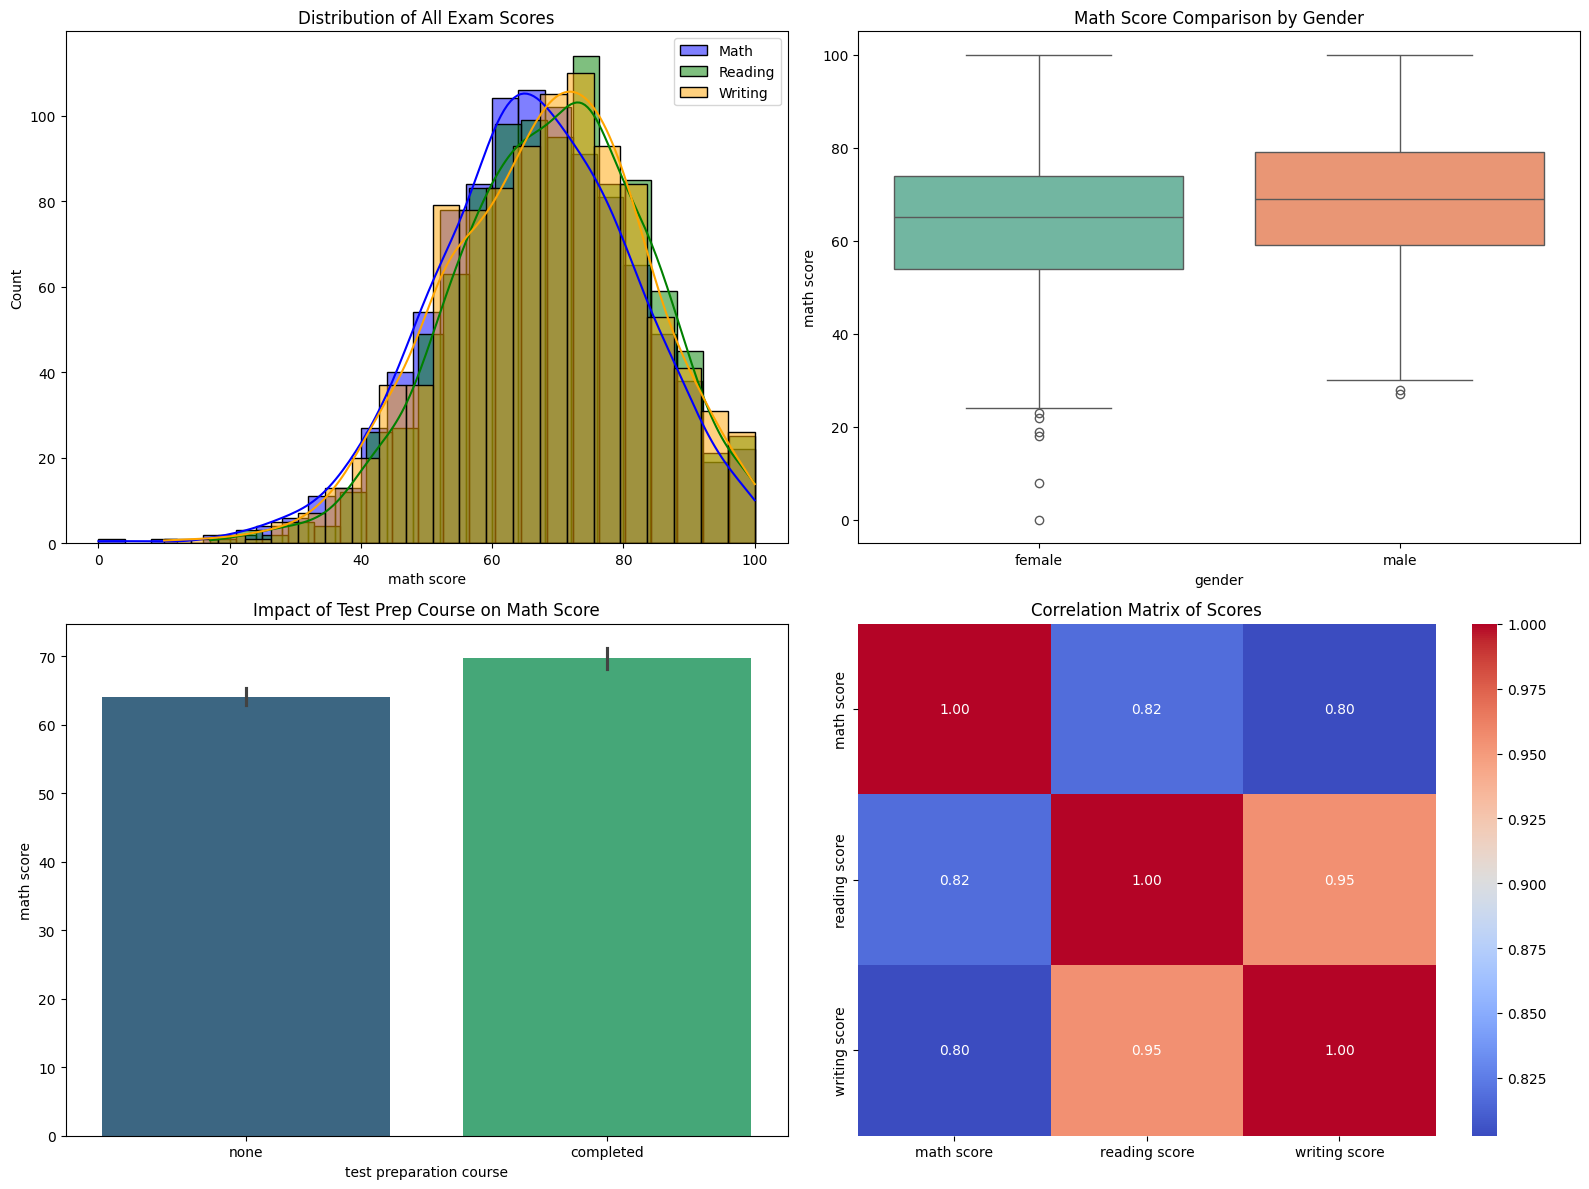

In [ ]:

plt.figure(figsize=(16, 12))


plt.subplot(2, 2, 1)
sns.histplot(df['math score'], color='blue', kde=True, label='Math')
sns.histplot(df['reading score'], color='green', kde=True, label='Reading')
sns.histplot(df['writing score'], color='orange', kde=True, label='Writing')
plt.title('Distribution of All Exam Scores')
plt.legend()


plt.subplot(2, 2, 2)
sns.boxplot(x='gender', y='math score', data=df, palette='Set2')
plt.title('Math Score Comparison by Gender')


plt.subplot(2, 2, 3)
sns.barplot(x='test preparation course', y='math score', data=df, palette='viridis')
plt.title('Impact of Test Prep Course on Math Score')


plt.subplot(2, 2, 4)

corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Scores')

plt.tight_layout()
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Preprocessing data for ML...")

# Target variable (y) humne 'math score'
# all features (X) to help in prediction
X = df.drop('math score', axis=1)
y = df['math score']

# Categorical columns ko One-Hot Encode karna (Text to Numbers)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train-Test Split (80% model training, 20%  testing )
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
  
  
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Successful!")
print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Testing Data Shape: {X_test_scaled.shape}")

Preprocessing data for ML...
Data Preprocessing Successful!
Training Data Shape: (800, 14)
Testing Data Shape: (200, 14)


In [15]:
# ==========================================
# CELL 4: Model Training & Evaluation
# ==========================================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models  dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

print("Training Regression Models...\n")

for name, model in models.items():
    # Model training
    model.fit(X_train_scaled, y_train)
    
    # Test data predictions
    y_pred = model.predict(X_test_scaled)
    
    # Regression Metrics calculation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
     # R2 Score main matrix 
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

# Results show in tables
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
display(results_df)

Training Regression Models...



,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.880433,4.214763,5.393994
2,Random Forest,0.849560,4.732893,6.050442
1,Decision Tree,0.710732,6.670000,8.389875


C:\Users\Mahar Faisal\AppData\Local\Temp\ipykernel_3856\3700784876.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Model', data=results_df, palette='mako')


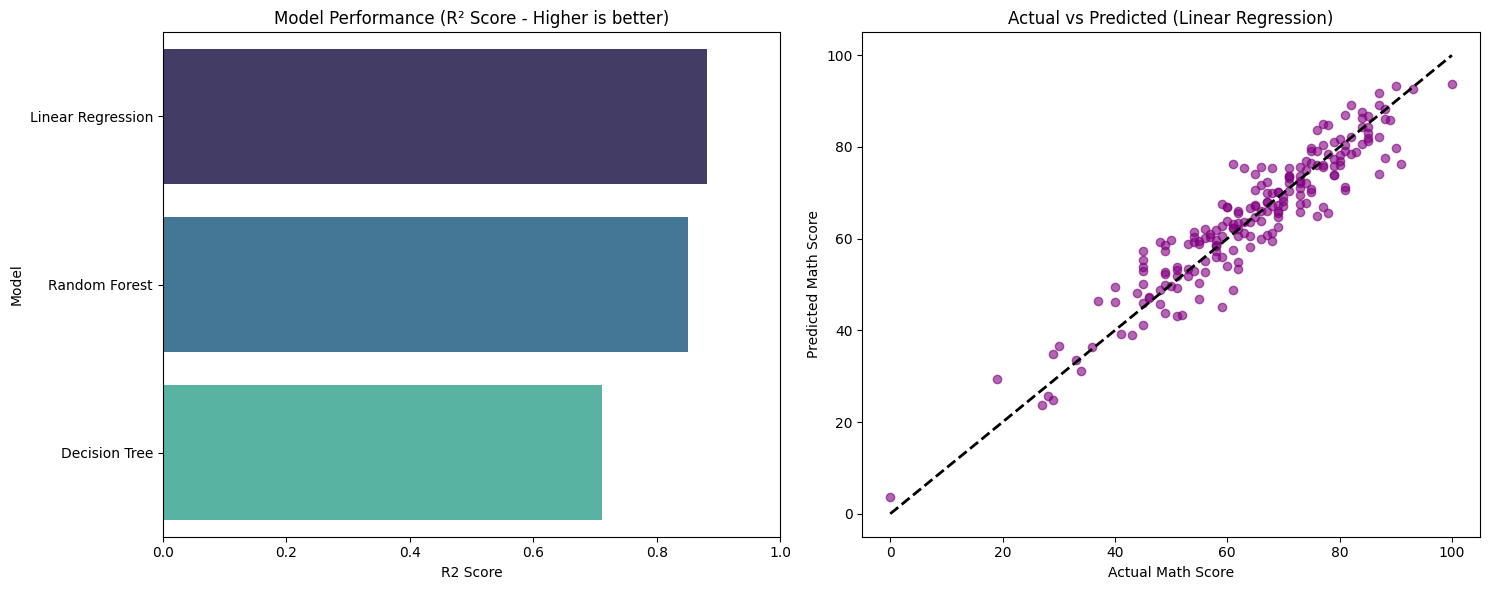

C:\Users\Mahar Faisal\AppData\Local\Temp\ipykernel_3856\3700784876.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='rocket')


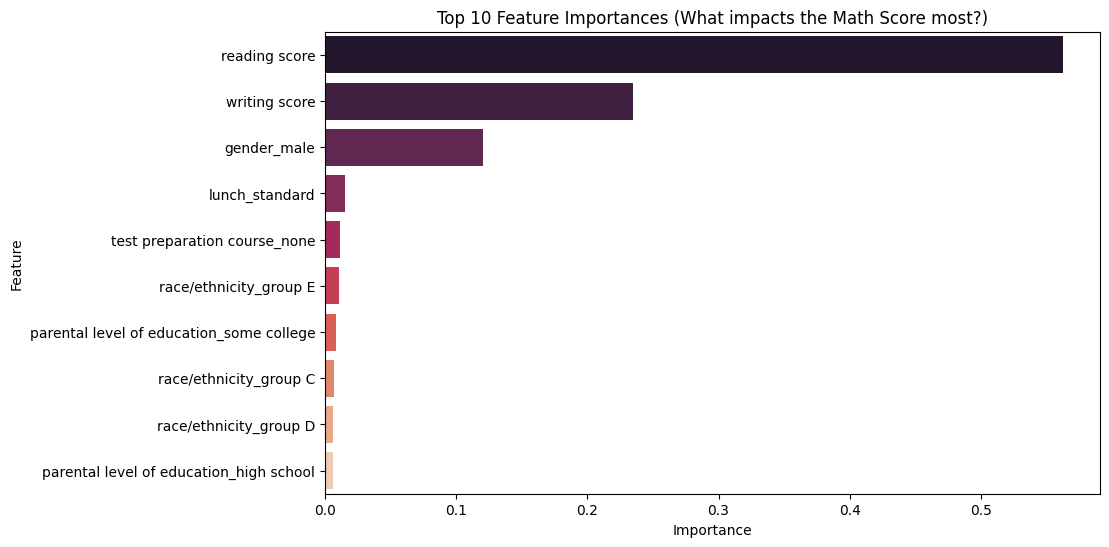

In [16]:
# ==========================================
# CELL 5: Visualizing Results & Feature Importance
# ==========================================
plt.figure(figsize=(15, 6))

# 1. R2 Score Comparison Graph
plt.subplot(1, 2, 1)
sns.barplot(x='R2 Score', y='Model', data=results_df, palette='mako')
plt.title('Model Performance (R² Score - Higher is better)')
plt.xlim(0, 1.0)

# 2. Actual vs Predicted Math Scores (For the best model - usually Linear Regression in this specific dataset)
best_model = LinearRegression()
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_best, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Perfect prediction line
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title('Actual vs Predicted (Linear Regression)')

plt.tight_layout()
plt.show()

# 3. Feature Importance (Random Forest se nikalte hain taake pata chale marks kis par depend karte hain)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)

importances = rf_model.feature_importances_
feature_names = X_encoded.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='rocket')
plt.title('Top 10 Feature Importances (What impacts the Math Score most?)')
plt.show()